**20260115 URA vs 3132.hk and 3191.hk vs QQQ**

The objective is to examine any correlation among URA, a nuclear energy focused ETF and 3132.hk (based upon  Bloomberg Global Semicon Top 20 Index (Price Return, HKD),) and 3191 (focused on Chinese semiconductor manufacturers).

One investment thesis is that semiconductor and related industries, such as LLM based tools, will require increased energy usage.   Nuclear fission power generation is one source that can provide stable, sizable energy output, with concerns on environment impacts when there is a major accident.

In [1]:
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HK_3191 = Global X China Semiconductor ETF 

HK_3132 = Samsung Bloomberg Global Semiconductor ETF

URA = URA = GLOBAL X URANIUM ETF

QQQ = Invesco QQQ Trust, Series

In [2]:
np.random.seed(0)

In [3]:
#import data
HK_3191 = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/3191.csv")
HK_3132 = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/3132.csv")
URA = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/URA.csv")
QQQ = pd.read_csv("E:/Workspace/Programming/Data/Price_Time_Series/QQQ.csv")

In [4]:
#change "Date" column datatype to datatime
HK_3191['Date']= pd.to_datetime(HK_3191['Date'], format='%m-%d-%y')
HK_3132['Date']= pd.to_datetime(HK_3132['Date'], format='%m-%d-%y')
URA['Date']= pd.to_datetime(URA['Date'], format='%m-%d-%y')
QQQ['Date']= pd.to_datetime(QQQ['Date'], format='%m-%d-%y')

In [5]:
#set each series index to its "Date" for combining the series to dataframe
HK_3191.set_index("Date", inplace = True)
HK_3132.set_index("Date", inplace = True)
URA.set_index("Date", inplace = True)
QQQ.set_index("Date", inplace = True)

In [6]:
#selecting "Close" data column
HK_3191 = HK_3191['Close']
HK_3132 = HK_3132['Close']
URA = URA['Close']
QQQ = QQQ['Close']

In [7]:
#rename the "Close" column to the instrument name.  These names will become the dataframe's column header
HK_3191.name = "HK_3191"
HK_3132.name = "HK_3132"
URA.name = "URA"
QQQ.name = "QQQ"

**What portfolio weights should I have if I only keep the current portfolio holdings?**

Let's use data since the beginning of 2024

In [8]:
price_data = pd.concat([HK_3191, HK_3132, URA, QQQ], axis=1)
price_data = price_data.loc[price_data.index > '2025-01-01']
price_data.head()

,HK_3191,HK_3132,URA,QQQ
Date,,,,
2025-01-02,39.08,23.50,28.11,510.23
2025-01-03,38.14,23.90,28.84,518.58
2025-01-06,37.64,24.30,29.28,524.54
2025-01-07,39.12,24.96,28.21,515.18
2025-01-08,38.80,24.44,27.84,515.27


In [9]:
#calculate daily return
price_return = price_data.pct_change(fill_method=None).dropna()
price_return.head()

,HK_3191,HK_3132,URA,QQQ
Date,,,,
2025-01-03,-0.024053,0.017021,0.025969,0.016365
2025-01-06,-0.013110,0.016736,0.015257,0.011493
2025-01-07,0.039320,0.027160,-0.036544,-0.017844
2025-01-08,-0.008180,-0.020833,-0.013116,0.000175
2025-01-13,-0.003603,-0.021470,-0.002576,-0.003214


In [10]:
#calculate annualized mean
price_return.mean()*252

HK_3191    0.786931
HK_3132    0.788790
URA        0.740948
QQQ        0.298926
dtype: float64

In [11]:
#calculate annualized standard deivation
price_return.std()*252

HK_3191    5.364246
HK_3132    5.302524
URA        7.487882
QQQ        3.656539
dtype: float64

In [12]:
price_return.corr()

,HK_3191,HK_3132,URA,QQQ
HK_3191,1.000000,0.301192,0.181448,0.176810
HK_3132,0.301192,1.000000,0.051382,-0.004953
URA,0.181448,0.051382,1.000000,0.512236
QQQ,0.176810,-0.004953,0.512236,1.000000


In [13]:
#calculate annualized covariance matrix.  This is required to calculate portfolio volatility/sd
price_return.cov()*252

,HK_3191,HK_3132,URA,QQQ
HK_3191,0.114187,0.033996,0.028921,0.013762
HK_3132,0.033996,0.111574,0.008096,-0.000381
URA,0.028921,0.008096,0.222494,0.055654
QQQ,0.013762,-0.000381,0.055654,0.053057


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

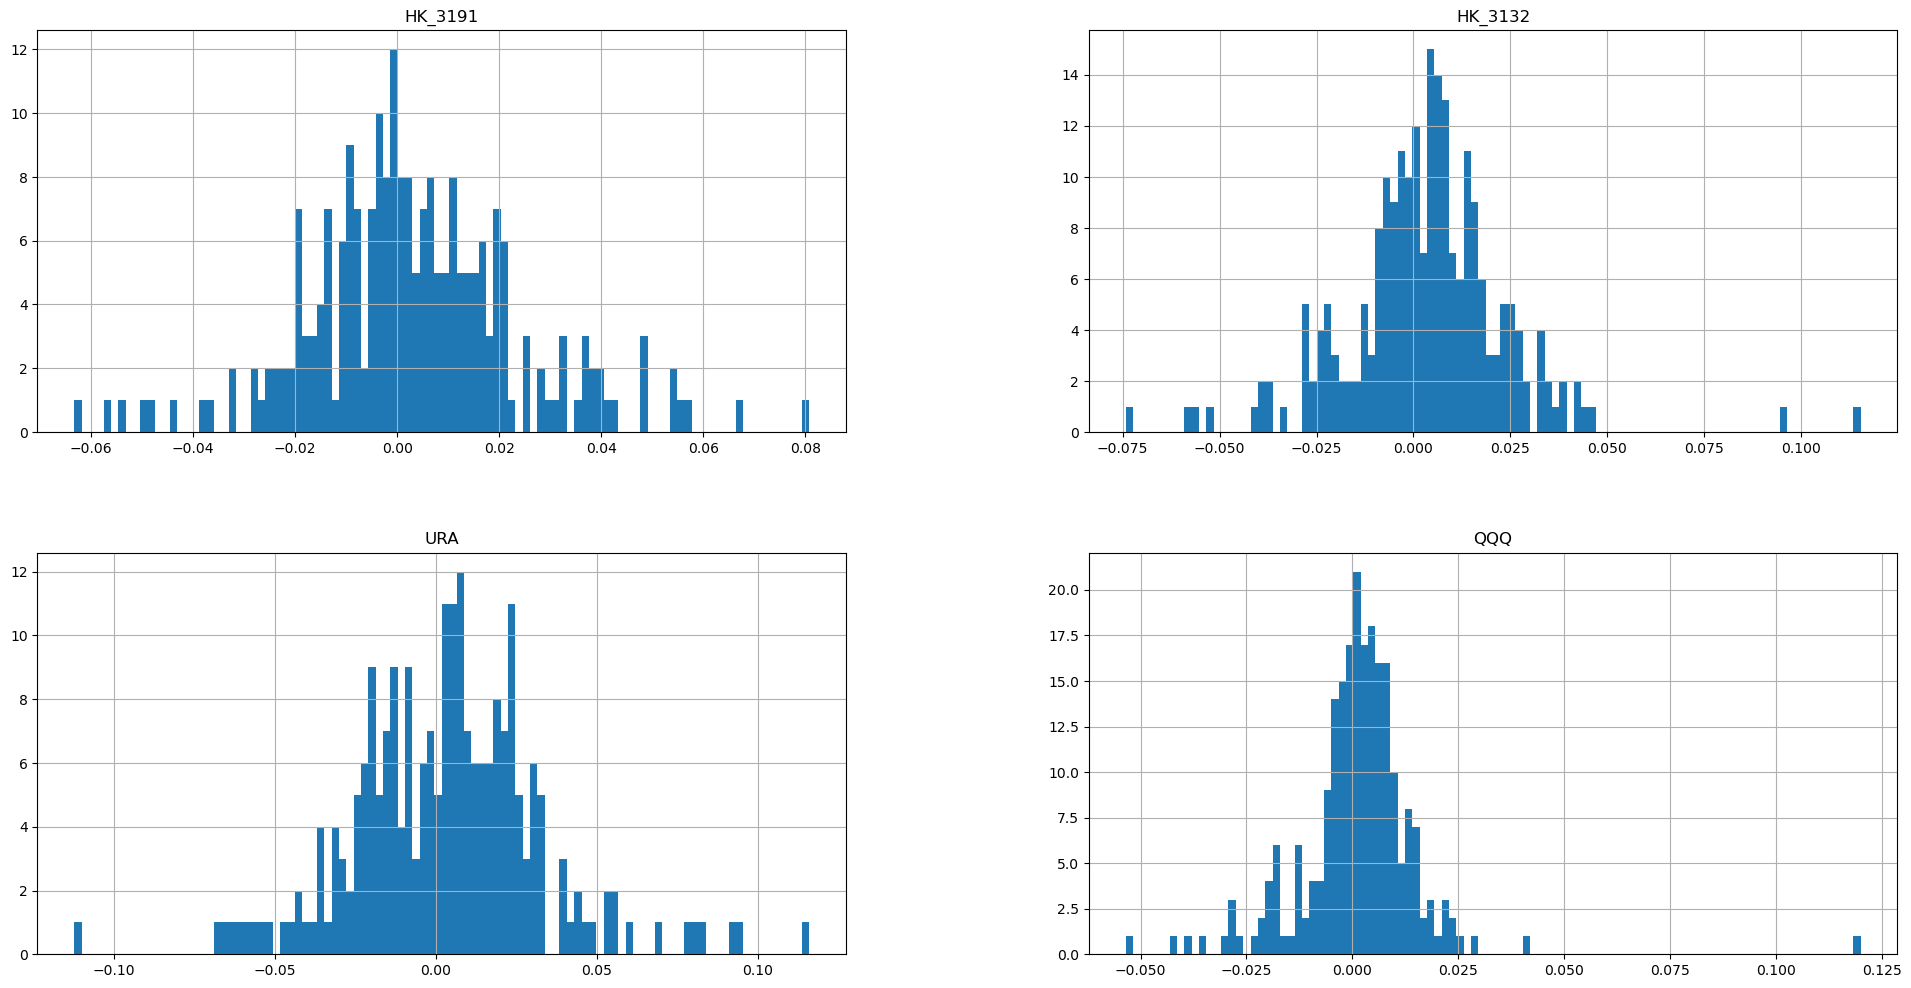

In [14]:
price_return.hist(figsize = (24,12), bins=100)
plt.tight_layout

Monte Carlo Simulation

The number of simulated portfolio is set to 100,000.   Risk free rate is assumed to be close to US Treasury 10-Y Bond yield.

The objective of the optimization is to maximize the Sharpe ratio of a portfolio.  The Sharpe Ratio is defined as:

(Portfolio Return - Risk Free Rate)/(Portfolio volatility)

In this exercise, we will annualize return and volatility (standard deviation).